# Week 3 - Machine Learning Regression Assignments

This notebook combines the Week 3 problem-identification, regression-modeling, and hyperparameter-tuning practice into one reproducible submission.

**Course dataset:** `data/insurance_pre.csv`
**Main result:** Gradient Boosting produced the strongest mean five-fold cross-validated R2 (0.855) and a held-out test R2 of 0.878 in the model comparison.


## Assignment 1: Problem Identification - Employee Attrition

### A) AI solution
Build an employee-attrition early-warning system from historical employee records. The model estimates whether an employee may leave so HR can plan retention and workforce continuity. The prediction must support human review rather than make an automatic employment decision.

### B) Three stages of problem identification

1. **Domain identification:** Human Resources / workforce planning.
2. **Learning identification:** Supervised learning, because historical examples have a known attrition label.
3. **Problem identification:** Binary classification, because the target is Attrition = Yes or No.

### C) Project name

**Employee Attrition Early-Warning System**

### D) Dummy dataset
The following fictional records demonstrate a suitable dataset structure. `employee_id` is an identifier and should not be used as a predictive feature.


In [2]:
import pandas as pd

employee_attrition_data = pd.DataFrame([
    ['E001', 26, 'Engineering', 2, 45000, 3, 2, 0, 'Yes'],
    ['E002', 41, 'Sales', 8, 82000, 4, 5, 1, 'No'],
    ['E003', 29, 'Support', 1, 38000, 2, 1, 0, 'Yes'],
    ['E004', 35, 'Engineering', 6, 76000, 5, 4, 2, 'No'],
    ['E005', 31, 'HR', 3, 52000, 3, 3, 1, 'No'],
    ['E006', 24, 'Sales', 1, 36000, 2, 1, 0, 'Yes'],
    ['E007', 46, 'Finance', 12, 98000, 4, 6, 2, 'No'],
    ['E008', 38, 'Support', 4, 61000, 3, 2, 1, 'Yes'],
    ['E009', 33, 'Engineering', 5, 70000, 4, 4, 1, 'No'],
    ['E010', 28, 'Marketing', 2, 48000, 3, 2, 0, 'Yes'],
    ['E011', 44, 'Sales', 10, 91000, 5, 6, 3, 'No'],
    ['E012', 30, 'Finance', 3, 57000, 4, 3, 1, 'No'],
], columns=[
    'employee_id', 'age', 'department', 'years_at_company',
    'monthly_income', 'job_satisfaction', 'overtime_hours_week',
    'promotions', 'attrition'
])
display(employee_attrition_data)
print('Dataset shape:', employee_attrition_data.shape)
print('Target distribution:')
display(employee_attrition_data['attrition'].value_counts().to_frame('employees'))


,employee_id,age,department,years_at_company,monthly_income,job_satisfaction,overtime_hours_week,promotions,attrition
0,E001,26,Engineering,2,45000,3,2,0,Yes
1,E002,41,Sales,8,82000,4,5,1,No
2,E003,29,Support,1,38000,2,1,0,Yes
3,E004,35,Engineering,6,76000,5,4,2,No
4,E005,31,HR,3,52000,3,3,1,No
5,E006,24,Sales,1,36000,2,1,0,Yes
6,E007,46,Finance,12,98000,4,6,2,No
7,E008,38,Support,4,61000,3,2,1,Yes
8,E009,33,Engineering,5,70000,4,4,1,No
9,E010,28,Marketing,2,48000,3,2,0,Yes


Dataset shape: (12, 9)
Target distribution:


,employees
attrition,
No,7
Yes,5


### Responsible-use check

Employee predictions are high impact. Before use, the project requires privacy review, bias testing, explainability, false-positive monitoring, and meaningful human oversight. The model must never be used to penalize an employee automatically.


## Assignment 2: Insurance Charges - Regression Modeling

## tl;dr
The dataset has **1338 rows and 6 columns**. Five regression algorithms were compared with a fixed 80/20 split and 5-fold cross-validation. **Gradient Boosting** was selected because it achieved the strongest mean cross-validated R2 (0.855) and a test R2 of 0.878.

## Context & Methods
**Problem statement:** Predict a person's insurance charges using age, sex, BMI, number of children, and smoking status.

### Key Assumptions
- `charges` is the continuous target, so this is supervised regression.
- Sex and smoker are nominal categorical variables and are one-hot encoded.
- A fixed random seed makes the split and model comparison reproducible.
- Model selection uses mean 5-fold CV R2 on the training set; the held-out test set is used once for final comparison.

## Data
### 1. Load and inspect the course dataset

In [3]:
from pathlib import Path
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.model_selection import train_test_split, KFold, cross_val_score
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error
from sklearn.linear_model import LinearRegression
from sklearn.svm import SVR
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.inspection import permutation_importance

DATA_PATH = Path('data/insurance_pre.csv')
data = pd.read_csv(DATA_PATH)
print('Shape:', data.shape)
display(data.head())
display(data.describe(include='all').T)

Shape: (1338, 6)


,age,sex,bmi,children,smoker,charges
0,19,female,27.900,0,yes,16884.92400
1,18,male,33.770,1,no,1725.55230
2,28,male,33.000,3,no,4449.46200
3,33,male,22.705,0,no,21984.47061
4,32,male,28.880,0,no,3866.85520


,count,unique,top,freq,mean,std,min,25%,50%,75%,max
age,1338.0,NaN,NaN,NaN,39.207025,14.04996,18.0,27.0,39.0,51.0,64.0
sex,1338,2,male,676,NaN,NaN,NaN,NaN,NaN,NaN,NaN
bmi,1338.0,NaN,NaN,NaN,30.663397,6.098187,15.96,26.29625,30.4,34.69375,53.13
children,1338.0,NaN,NaN,NaN,1.094918,1.205493,0.0,0.0,1.0,2.0,5.0
smoker,1338,2,no,1064,NaN,NaN,NaN,NaN,NaN,NaN,NaN
charges,1338.0,NaN,NaN,NaN,13270.422265,12110.011237,1121.8739,4740.28715,9382.033,16639.912515,63770.42801


### 2. Validate data quality

In [4]:
quality_summary = pd.DataFrame({
    'metric': ['rows', 'columns', 'duplicate rows', 'total missing values'],
    'value': [len(data), data.shape[1], data.duplicated().sum(), data.isna().sum().sum()]
})
display(quality_summary)
display(data.isna().sum().to_frame('missing_values'))

,metric,value
0,rows,1338
1,columns,6
2,duplicate rows,1
3,total missing values,0


,missing_values
age,0
sex,0
bmi,0
children,0
smoker,0
charges,0


### 3. Preprocess and split
Numeric features are standardized. Nominal features are one-hot encoded inside a pipeline to prevent leakage.

In [5]:
X = data.drop(columns='charges')
y = data['charges']
categorical_features = ['sex', 'smoker']
numeric_features = ['age', 'bmi', 'children']
preprocess = ColumnTransformer([
    ('num', StandardScaler(), numeric_features),
    ('cat', OneHotEncoder(handle_unknown='ignore', drop='first'), categorical_features),
])
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, random_state=42
)
print('Training rows:', len(X_train), 'Test rows:', len(X_test))

Training rows: 1070 Test rows: 268


## Results
### 4. Compare five regression algorithms

In [6]:
models = {
    'Linear Regression': LinearRegression(),
    'Support Vector Regressor': SVR(C=1000, epsilon=0.1, gamma='scale'),
    'Decision Tree': DecisionTreeRegressor(max_depth=5, min_samples_leaf=5, random_state=42),
    'Random Forest': RandomForestRegressor(n_estimators=300, max_depth=8, min_samples_leaf=2, random_state=42, n_jobs=1),
    'Gradient Boosting': GradientBoostingRegressor(n_estimators=200, learning_rate=0.03, max_depth=2, random_state=42),
}
cv = KFold(n_splits=5, shuffle=True, random_state=42)
rows, fitted_models = [], {}
for name, estimator in models.items():
    pipeline = Pipeline([('preprocess', preprocess), ('model', estimator)])
    cv_scores = cross_val_score(pipeline, X_train, y_train, cv=cv, scoring='r2', n_jobs=1)
    pipeline.fit(X_train, y_train)
    prediction = pipeline.predict(X_test)
    rows.append({
        'Model': name, 'CV R2 Mean': cv_scores.mean(), 'CV R2 Std': cv_scores.std(),
        'Test R2': r2_score(y_test, prediction),
        'MAE': mean_absolute_error(y_test, prediction),
        'RMSE': mean_squared_error(y_test, prediction) ** 0.5,
    })
    fitted_models[name] = pipeline
results = pd.DataFrame(rows).sort_values('CV R2 Mean', ascending=False).reset_index(drop=True)
display(results.round({'CV R2 Mean':3, 'CV R2 Std':3, 'Test R2':3, 'MAE':0, 'RMSE':0}))

,Model,CV R2 Mean,CV R2 Std,Test R2,MAE,RMSE
0,Gradient Boosting,0.855,0.031,0.878,2505.0,4354.0
1,Decision Tree,0.845,0.031,0.869,2628.0,4510.0
2,Random Forest,0.841,0.031,0.870,2460.0,4500.0
3,Linear Regression,0.739,0.030,0.781,4213.0,5829.0
4,Support Vector Regressor,0.571,0.045,0.645,3330.0,7420.0


### 5. Visualize model performance

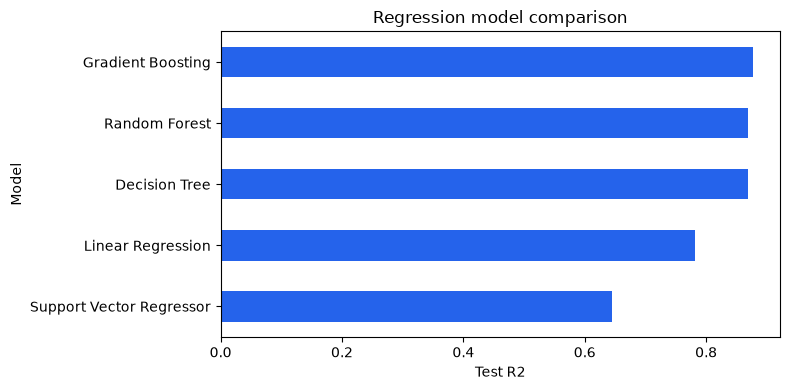

In [7]:
ax = results.sort_values('Test R2').plot.barh(x='Model', y='Test R2', legend=False, color='#2563eb', figsize=(8,4))
ax.set_title('Regression model comparison')
ax.set_xlabel('Test R2')
plt.tight_layout(); plt.show()

### 6. Inspect the selected model

Selected model: Gradient Boosting
Test R2: 0.8779
MAE: 2505.38
RMSE: 4354.39


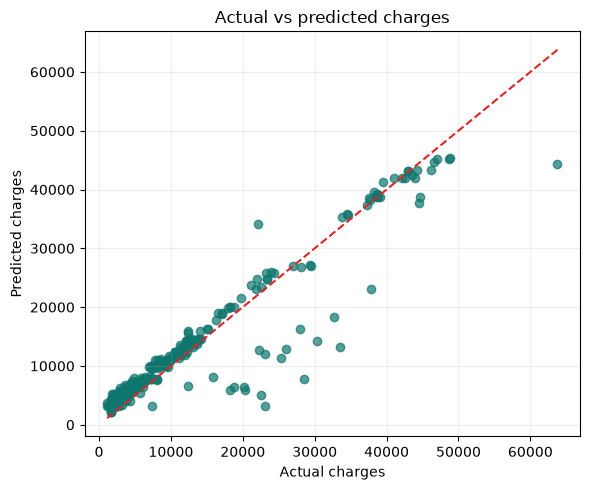

In [8]:
best_name = results.loc[0, 'Model']
best_model = fitted_models[best_name]
best_prediction = best_model.predict(X_test)
print('Selected model:', best_name)
print('Test R2:', round(r2_score(y_test, best_prediction), 4))
print('MAE:', round(mean_absolute_error(y_test, best_prediction), 2))
print('RMSE:', round(mean_squared_error(y_test, best_prediction) ** 0.5, 2))

plt.figure(figsize=(6,5))
plt.scatter(y_test, best_prediction, alpha=.7, color='#0f766e')
low = min(y_test.min(), best_prediction.min()); high = max(y_test.max(), best_prediction.max())
plt.plot([low, high], [low, high], '--', color='#dc2626')
plt.xlabel('Actual charges'); plt.ylabel('Predicted charges'); plt.title('Actual vs predicted charges')
plt.grid(alpha=.2); plt.tight_layout(); plt.show()

### 7. Explain the selected model with permutation importance

,Feature,Importance
4,smoker,1.385417
2,bmi,0.224138
0,age,0.177982
3,children,0.009666
1,sex,0.000066


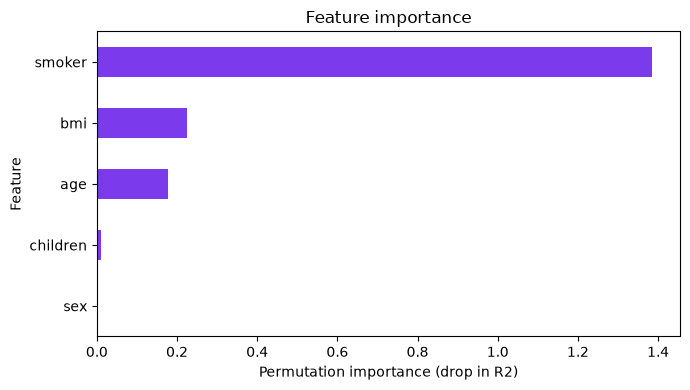

In [9]:
importance = permutation_importance(best_model, X_test, y_test, n_repeats=20, random_state=42, scoring='r2')
importance_table = pd.DataFrame({'Feature': X.columns, 'Importance': importance.importances_mean}).sort_values('Importance', ascending=False)
display(importance_table)
importance_table.sort_values('Importance').plot.barh(x='Feature', y='Importance', legend=False, color='#7c3aed', figsize=(7,4))
plt.xlabel('Permutation importance (drop in R2)'); plt.title('Feature importance')
plt.tight_layout(); plt.show()

## Assignment 3: Hyperparameter Tuning Practice

A compact `GridSearchCV` checks multiple Gradient Boosting configurations using three-fold cross-validation on the training data. The held-out test set remains separate from the parameter search.


In [10]:
from sklearn.model_selection import GridSearchCV

tuning_pipeline = Pipeline([
    ('preprocess', preprocess),
    ('model', GradientBoostingRegressor(random_state=42)),
])
parameter_grid = {
    'model__n_estimators': [100, 200],
    'model__learning_rate': [0.03, 0.05],
    'model__max_depth': [2, 3],
}
grid_search = GridSearchCV(
    tuning_pipeline, parameter_grid, cv=3, scoring='r2', n_jobs=1
)
grid_search.fit(X_train, y_train)
tuned_prediction = grid_search.predict(X_test)
tuned_test_r2 = r2_score(y_test, tuned_prediction)
print('Best parameters:', grid_search.best_params_)
print('Best CV R2:', round(grid_search.best_score_, 4))
print('Held-out test R2:', round(tuned_test_r2, 4))


Best parameters: {'model__learning_rate': 0.05, 'model__max_depth': 2, 'model__n_estimators': 200}
Best CV R2: 0.8513
Held-out test R2: 0.8798


## Regression Concept Review

- **Regression** predicts a continuous numeric output such as insurance charges.
- **R2** measures the proportion of target variance explained by the model; higher is better on comparable held-out data.
- **MAE** is the average absolute prediction error, while **RMSE** penalizes larger errors more strongly.
- A **train/test split** protects the final evaluation from training leakage.
- **Cross-validation** reduces dependence on one lucky split.
- **GridSearchCV** compares parameter combinations using cross-validation.
- Categorical nominal values are encoded, and scaling is applied inside the pipeline to keep preprocessing reproducible.


## Takeaways
- **Final model:** Gradient Boosting.
- **Why selected:** It had the highest mean 5-fold CV R2 (0.855); its held-out test R2 was 0.878.
- The final test MAE was approximately 2,505 charge units and RMSE was 4,354.
- The model is suitable for this assignment comparison, but it should not be used for real insurance pricing without fairness, calibration, drift, and domain reviews.